## Importaciones y Constantes

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import math

EPS = 1e-9

## Lectura y Validación de Polígonos

In [6]:
def read_polygons_from_txt(filename):
    P = []
    Q = []
    current = None
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('# Polygon P'):
                current = P
            elif line.startswith('# Polygon Q'):
                current = Q
            elif line and not line.startswith('#'):
                parts = line.split()
                if len(parts) == 2:
                    x, y = float(parts[0]), float(parts[1])
                    if current is not None:
                        current.append((x, y))
    return P, Q

def is_convex(polygon):
    if len(polygon) < 3:
        return False
    n = len(polygon)
    sign = 0
    for i in range(n):
        p1 = polygon[i]
        p2 = polygon[(i + 1) % n]
        p3 = polygon[(i + 2) % n]
        cross = (p2[0] - p1[0]) * (p3[1] - p2[1]) - (p2[1] - p1[1]) * (p3[0] - p2[0])
        if abs(cross) > EPS:
            if sign == 0:
                sign = 1 if cross > 0 else -1
            elif (cross > 0 and sign < 0) or (cross < 0 and sign > 0):
                return False
    return True

## Funciones Geométricas Auxiliares

In [7]:
def on_segment(p, q, r):
    if (min(p[0], r[0]) <= q[0] <= max(p[0], r[0]) and
        min(p[1], r[1]) <= q[1] <= max(p[1], r[1])):
        return True
    return False

def orientation(p, q, r):
    val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
    if abs(val) < EPS:
        return 0
    return 1 if val > 0 else 2

def edges_intersect(p1, p2, q1, q2):
    o1 = orientation(p1, p2, q1)
    o2 = orientation(p1, p2, q2)
    o3 = orientation(q1, q2, p1)
    o4 = orientation(q1, q2, p2)

    if o1 != o2 and o3 != o4:
        return True

    if o1 == 0 and on_segment(p1, q1, p2):
        return True
    if o2 == 0 and on_segment(p1, q2, p2):
        return True
    if o3 == 0 and on_segment(q1, p1, q2):
        return True
    if o4 == 0 and on_segment(q1, p2, q2):
        return True

    return False

def point_in_polygon(point, polygon):
    n = len(polygon)
    inside = False
    x, y = point
    p1x, p1y = polygon[0]
    for i in range(1, n + 1):
        p2x, p2y = polygon[i % n]
        if y > min(p1y, p2y):
            if y <= max(p1y, p2y):
                if x <= max(p1x, p2x):
                    if p1y != p2y:
                        xinters = (y - p1y) * (p2x - p1x) / (p2y - p1y) + p1x
                    if p1x == p2x or x <= xinters:
                        inside = not inside
        p1x, p1y = p2x, p2y
    return inside

## Algoritmo de Intersección

In [8]:
def intersect_convex_polygons(P, Q):
    intersection_points = []
    n = len(P)
    m = len(Q)

    for i in range(n):
        for j in range(m):
            p1 = P[i]
            p2 = P[(i + 1) % n]
            q1 = Q[j]
            q2 = Q[(j + 1) % m]
            if edges_intersect(p1, p2, q1, q2):
                denom = (p1[0] - p2[0]) * (q1[1] - q2[1]) - (p1[1] - p2[1]) * (q1[0] - q2[0])
                if abs(denom) > EPS:
                    t = ((q1[0] - p1[0]) * (q2[1] - q1[1]) - (q1[1] - p1[1]) * (q2[0] - q1[0])) / denom
                    s = ((q1[0] - p1[0]) * (p2[1] - p1[1]) - (q1[1] - p1[1]) * (p2[0] - p1[0])) / denom
                    if 0 <= t <= 1 and 0 <= s <= 1:
                        ix = p1[0] + t * (p2[0] - p1[0])
                        iy = p1[1] + t * (p2[1] - p1[1])
                        inter_pt = (ix, iy)
                        if inter_pt not in intersection_points:
                            intersection_points.append(inter_pt)

    for pt in P:
        if point_in_polygon(pt, Q):
            if pt not in intersection_points:
                intersection_points.append(pt)

    for pt in Q:
        if point_in_polygon(pt, P):
            if pt not in intersection_points:
                intersection_points.append(pt)

    if not intersection_points:
        return []

    cx = sum(x for x, y in intersection_points) / len(intersection_points)
    cy = sum(y for x, y in intersection_points) / len(intersection_points)
    intersection_points.sort(key=lambda p: (math.atan2(p[1] - cy, p[0] - cx), p[0]))

    if intersection_points and intersection_points[0] != intersection_points[-1]:
        intersection_points.append(intersection_points[0])

    return intersection_points

## Visualización

In [9]:
def plot_polygons(P, Q, intersection_pts, intersection_polygon):
    fig, ax = plt.subplots()
    ax.set_aspect('equal')

    P_np = np.array(P + [P[0]])
    ax.plot(P_np[:, 0], P_np[:, 1], 'b-', label='Polygon P')

    Q_np = np.array(Q + [Q[0]])
    ax.plot(Q_np[:, 0], Q_np[:, 1], 'g--', label='Polygon Q')

    if intersection_polygon:
        inter_np = np.array(intersection_polygon)
        ax.fill(inter_np[:, 0], inter_np[:, 1], 'r', alpha=0.5, label='Intersection')

    for idx, pt in enumerate(intersection_pts):
        ax.plot(pt[0], pt[1], 'ro')
        ax.text(pt[0], pt[1], f'{idx+1}', fontsize=12, ha='right')

    ax.legend()
    plt.savefig('intersection.png')
    plt.show()

## Main

Intersección encontrada con 4 vértices:
(1.000, 0.000)
(2.000, 1.000)
(1.000, 2.000)
(0.000, 1.000)


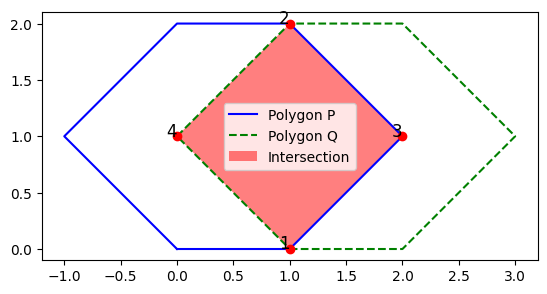

In [10]:
def main():
    filename = 'poligonos.txt'
    try:
        P, Q = read_polygons_from_txt(filename)
    except FileNotFoundError:
        print(f"Error: Archivo '{filename}' no encontrado.")
        return

    if not is_convex(P):
        print("Error: Polygon P no es convexo.")
        return
    if not is_convex(Q):
        print("Error: Polygon Q no es convexo.")
        return

    intersection = intersect_convex_polygons(P, Q)

    if intersection:
        print(f"Intersección encontrada con {len(intersection)-1} vértices:")
        for pt in intersection[:-1]:  # Excluir el cierre
            print(f"({pt[0]:.3f}, {pt[1]:.3f})")
    else:
        print("No hay intersección.")

    intersection_pts = list(set(intersection[:-1])) if intersection else []
    plot_polygons(P, Q, intersection_pts, intersection)

if __name__ == "__main__":
    main()